In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [ ]:
!ls ./drive/MyDrive/data/w*.csv

./drive/MyDrive/data/widget_sales.csv


In [ ]:
df = pd.read_csv('./drive/MyDrive/data/widget_sales.csv')

In [ ]:
df

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108
...,...
495,64.087371
496,63.992081
497,63.029894
498,61.671797


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   widget_sales  500 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


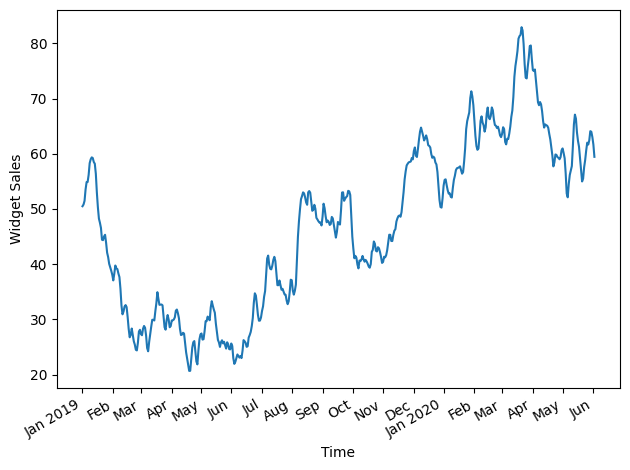

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget Sales')
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
ADF_result = adfuller(df['widget_sales'])
ADF_result[0], ADF_result[1] # 통계량, p-value

(np.float64(-1.5121662069359048), np.float64(0.5274845352272605))

In [ ]:
widget_sales_diff = np.diff(df['widget_sales'], n=1) # 1차차분 n=1

In [ ]:
len(widget_sales_diff)

499

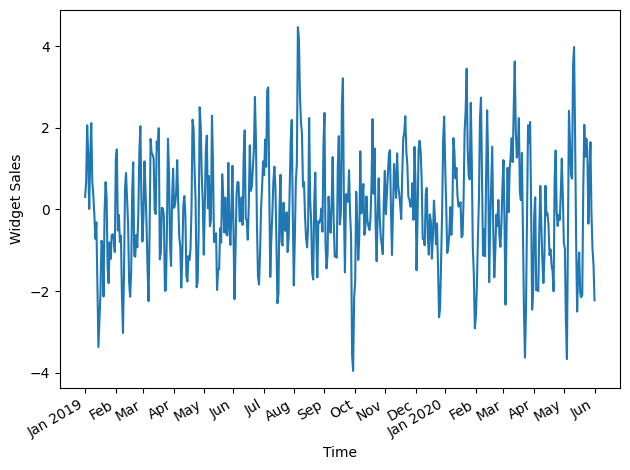

In [ ]:
fig, ax = plt.subplots()
ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget Sales')
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
ADF_result = adfuller(widget_sales_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19


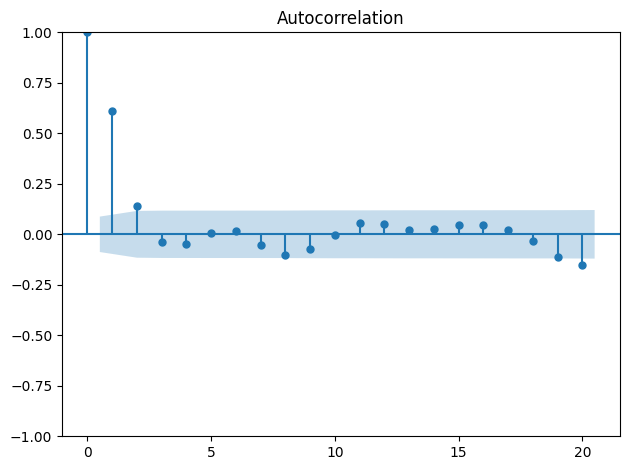

In [ ]:
plot_acf(widget_sales_diff, lags=20)
plt.tight_layout()
plt.show()

ARIMA

시계열 자료들 간의 상관관계를 구조화한 시계열 모형

ARIMA = AR, I, MA
- AR : 현재의 시계열 값이 과거의 시계열 값에 어떻게 의존하여 변하는지를  나타냄
- MA : 현재의 시계열 값이 과거의 오차값에 어떻게 의존하여 변하는 지를 나타냄
- I : 시계열 자료를 차분하는 것으로, 차분 된 결과를 전 시점에 대해 더하면  원래 값이 됨

In [ ]:
df_diff = pd.DataFrame({'widget_sales_diff':widget_sales_diff})

In [ ]:
train = df_diff[:int(0.9 * len(df_diff))]
test = df_diff[int(0.9 * len(df_diff)):]

In [ ]:
train.shape

(449, 1)

In [ ]:
test.shape

(50, 1)

In [ ]:
train

,widget_sales_diff
0,0.308778
1,0.672265
2,2.064470
3,1.330880
4,0.012034
...,...
444,-0.531086
445,0.577963
446,-0.409040
447,-1.249779


In [ ]:
test

,widget_sales_diff
449,-1.170131
450,0.580967
451,-0.144902
452,-0.096564
453,-0.372334
454,-1.118891
455,-0.979693
456,-1.369431
457,-1.517477
458,-2.006735


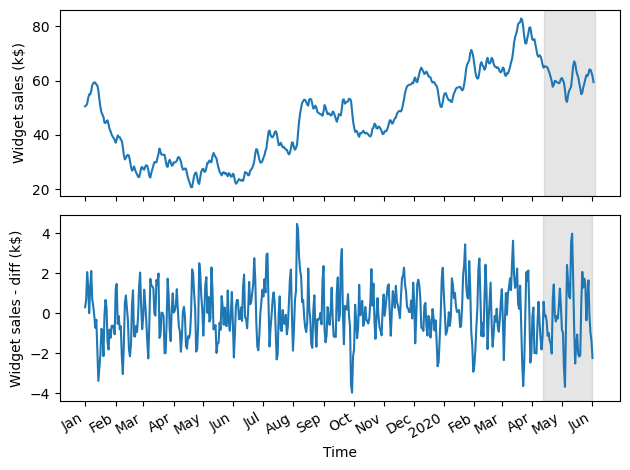

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)
ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()

MA(2)

In [ ]:
# MA(2)일 때
model = SARIMAX(df_diff, order=(0, 0, 2))
res = model.fit()

In [ ]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

50시간의 예측 값을 가지기 위해, 시간 간격 2씩 예측 하는 과정을 25번 수행해야 한다.

--> rolling forecast 고려

In [ ]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon
    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value
    elif method == 'MA':
        pred_MA = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)
        return pred_MA

In [ ]:
pred_df = test.copy()

In [ ]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

In [ ]:
pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA

In [ ]:
pred_df

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994
454,-1.118891,0.032183,-0.096564,0.115810
455,-0.979693,0.028764,-1.118891,-0.795666
456,-1.369431,0.028764,-1.118891,-0.191286
457,-1.517477,0.023498,-1.369431,-0.922824
458,-2.006735,0.023498,-1.369431,-0.254060


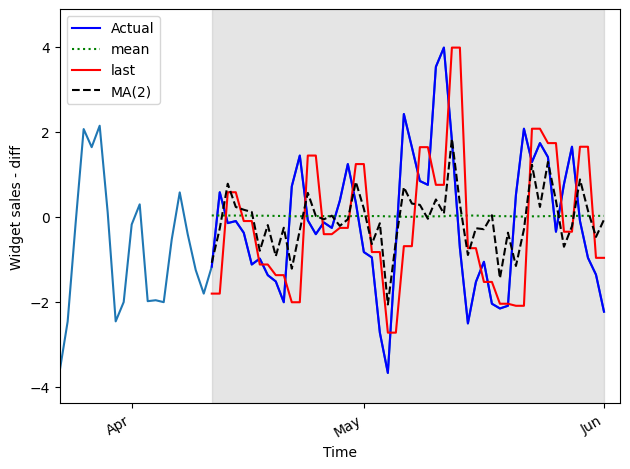

In [ ]:
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='Actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-', label='last')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff')

ax.axvspan(449, 498, color='#808080', alpha=0.2)
ax.set_xlim(430, 500)
plt.xticks(
    [439, 468, 498],
    ['Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

In [ ]:
mse_mean, mse_last, mse_MA

(2.5606299456880537, 3.2494260812249225, 1.9481714497863145)

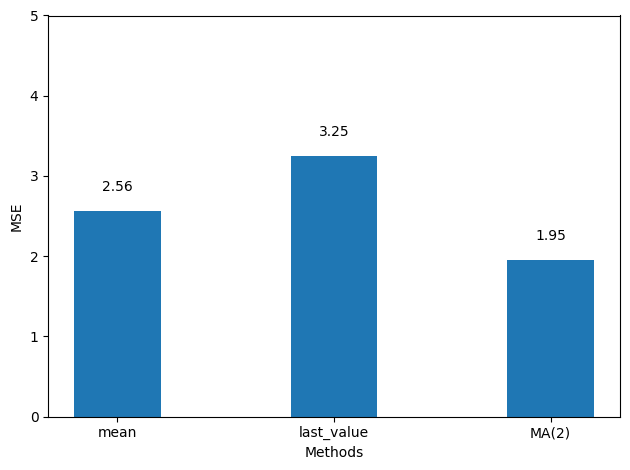

In [ ]:
fig, ax = plt.subplots()
x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]
ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)
for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')
plt.tight_layout()

450 = 449 + 450$'$

451 = 450 + 451$'$ = 449 + 450$'$ + 451$'$

452 = 449 + 450$'$ + 451$'$ + 452$'$


In [ ]:
df['pred_widget_sales'] = pd.Series()
df['pred_widget_sales'][450:] = df['widget_sales'].iloc[449] + pred_df['pred_MA'].cumsum()

/tmp/ipykernel_23382/3382879307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pred_widget_sales'][450:] = df['widget_sales'].iloc[449] + pred_df['pred_MA'].cumsum()
/tmp/ipykernel_23382/3382879307.py:2: SettingWithCopyWarning: 
A v

In [ ]:
df

,widget_sales,pred_widget_sales
0,50.496714,NaN
1,50.805493,NaN
2,51.477758,NaN
3,53.542228,NaN
4,54.873108,NaN
...,...,...
495,64.087371,61.505333
496,63.992081,62.388523
497,63.029894,62.535902
498,61.671797,62.066104


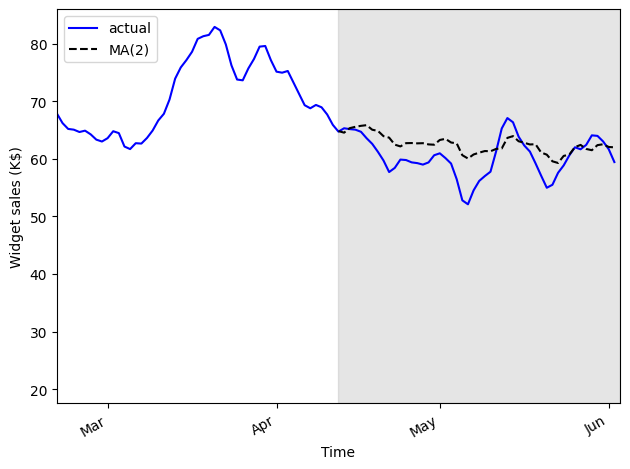

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')
ax.axvspan(450, 500, color='#808080', alpha=0.2)
ax.set_xlim(400, 500)
plt.xticks(
    [409, 439, 468, 498],
    ['Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
from sklearn.metrics import mean_absolute_error
# 예측된 차수값의 누적합계
mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:], df['pred_widget_sales'].iloc[450:])
# +- 2.7 차이남
print(mae_MA_undiff)

2.765664110147504


AR (autoregressive, 자기회귀)
- AR(p) model

$$
y_t = C + ø_1 y_{t-1} + … + ø_{p} y_{t-p} + ϵ_t
$$

- 현재값이 과거값에 선형적으로 의존 -> 자기 자신에게 회귀하는 프로세스 -> 자기회귀 과정

In [ ]:
!ls ./drive/MyDrive/data/foot*.csv

./drive/MyDrive/data/foot_traffic.csv


In [ ]:
df = pd.read_csv('./drive/MyDrive/data/foot_traffic.csv')

In [ ]:
df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   foot_traffic  1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB


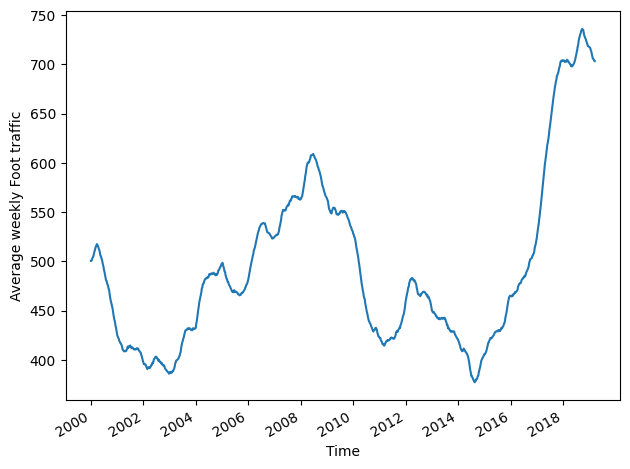

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly Foot traffic')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
ADF_reusult = adfuller(df['foot_traffic'])
print(f"ADF Statistic: {ADF_reusult[0]}")
print(f"p-value: {ADF_reusult[1]}")

ADF Statistic: -1.1758885999240747
p-value: 0.683880891789619


In [ ]:
foot_traffic_diff = np.diff(df['foot_traffic'], n=1)

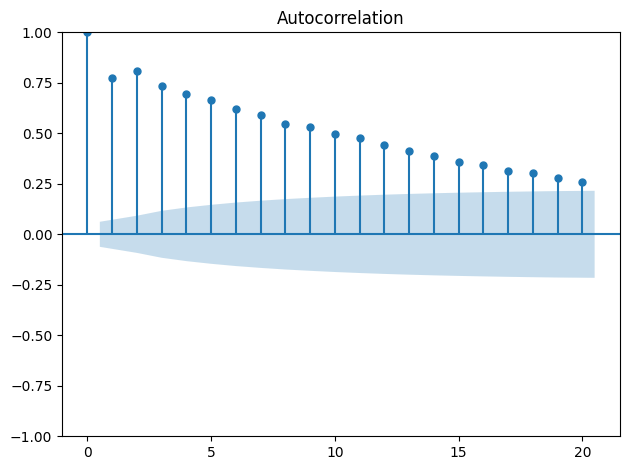

In [ ]:
plot_acf(foot_traffic_diff, lags=20)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

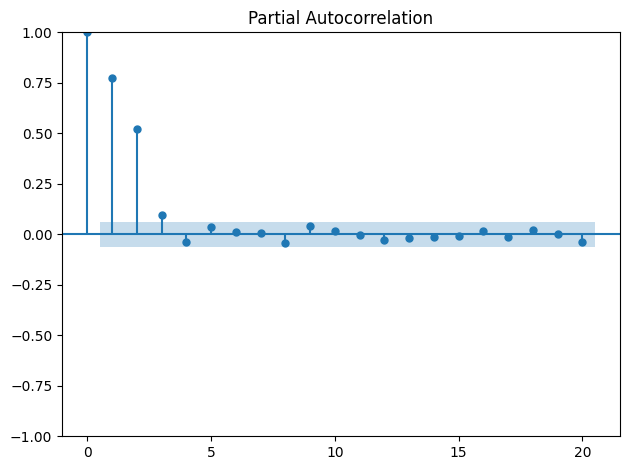

In [ ]:
plot_pacf(foot_traffic_diff, lags=20)
plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

ma2 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.50])

In [ ]:
AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

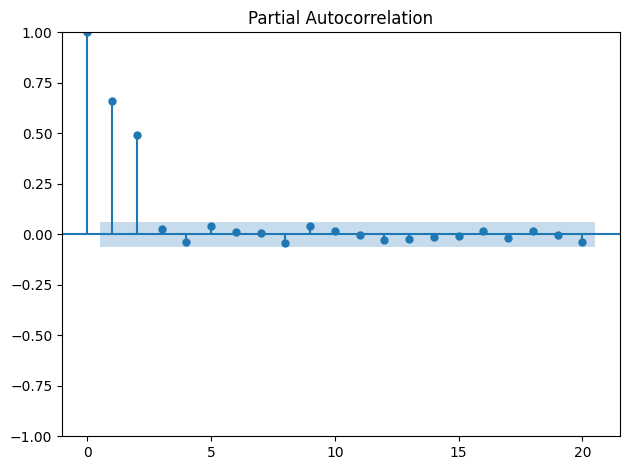

In [ ]:
plot_pacf(AR2_process, lags=20)
plt.tight_layout()
plt.show()

위에서 한건 AR(3) 프로세스이다.

In [ ]:
df_diff = pd.DataFrame({'foot_traffic_diff':foot_traffic_diff})
train = df_diff[:-52]
test = df_diff[-52:]
train.shape

(947, 1)

In [ ]:
test.shape

(52, 1)

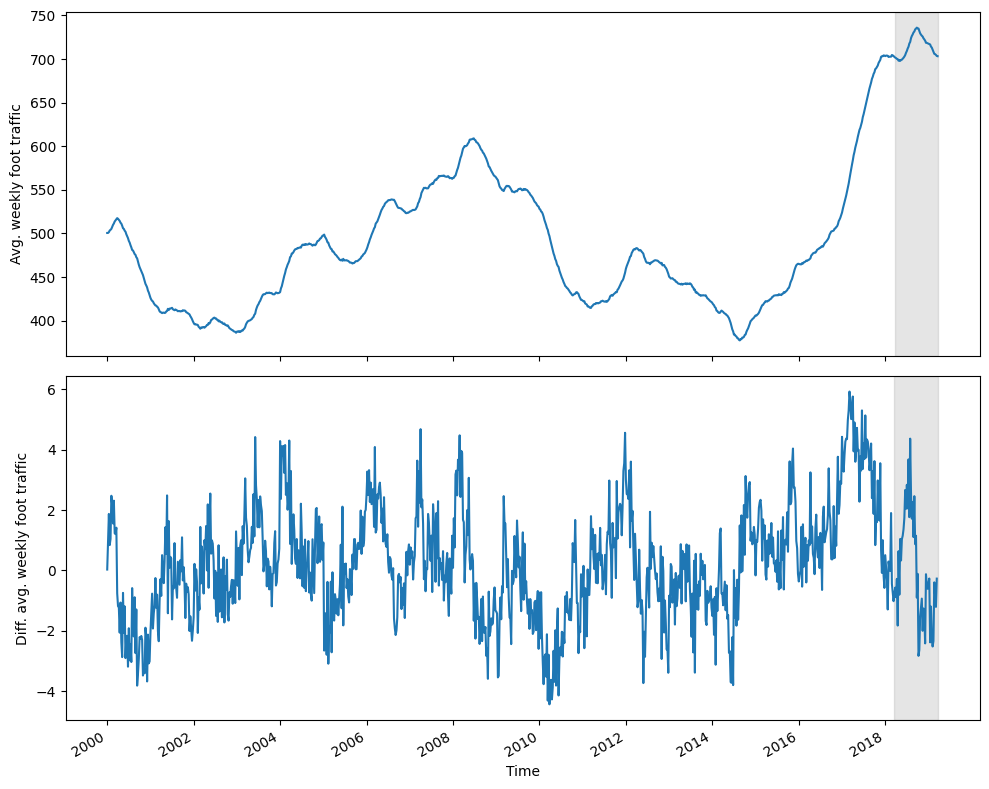

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))
ax1.plot(df['foot_traffic'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Avg. weekly foot traffic')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)
ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon
    end_idx = train_len
    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value
    elif method == 'AR':
        pred_AR = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(3,0,0)) # AR(3)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
        #print(res.params) # 파라미터값 볼수 있다.
        return pred_AR

In [ ]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

In [ ]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'AR')

In [ ]:
# pred_df = test.copy()

In [ ]:
# pred_df['pred_mean'] = pred_mean
# pred_df['pred_last_value'] = pred_last_value
# pred_df['pred_AR'] = pred_AR
test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

/tmp/ipykernel_23382/3182980033.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_mean'] = pred_mean
/tmp/ipykernel_23382/3182980033.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_last_value'] = pred_last_value
/tmp/ipykernel_23382/3182980033.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

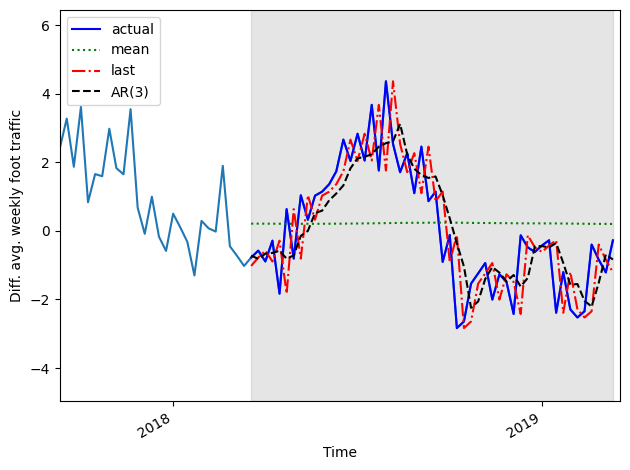

In [ ]:
fig, ax = plt.subplots()
ax.plot(df_diff['foot_traffic_diff'])
ax.plot(test['foot_traffic_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_AR'], 'k--', label='AR(3)')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Diff. avg. weekly foot traffic')
ax.axvspan(947, 998, color='#808080', alpha=0.2)
ax.set_xlim(920, 999)
plt.xticks([936, 988],[2018, 2019])
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
mse_mean = mean_squared_error(test['foot_traffic_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['foot_traffic_diff'], test['pred_last_value'])
mse_AR = mean_squared_error(test['foot_traffic_diff'], test['pred_AR'])

In [ ]:
print(mse_mean, mse_last, mse_AR)

3.1079979374701447 1.448730118495964 0.924247916284841


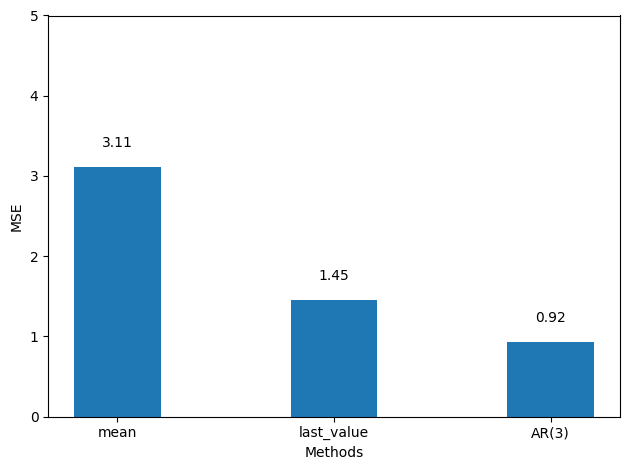

In [ ]:
fig, ax = plt.subplots()
x = ['mean', 'last_value', 'AR(3)']
y = [mse_mean, mse_last, mse_AR]
ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)
for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')
plt.tight_layout()

In [ ]:
df['pred_foot_traffic'] = pd.Series()
df['pred_foot_traffic'][948:] = df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum()

/tmp/ipykernel_23382/3875516694.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pred_foot_traffic'][948:] = df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum()
/tmp/ipykernel_23382/3875516694.py:2: SettingWithCopyWarning: 
A valu

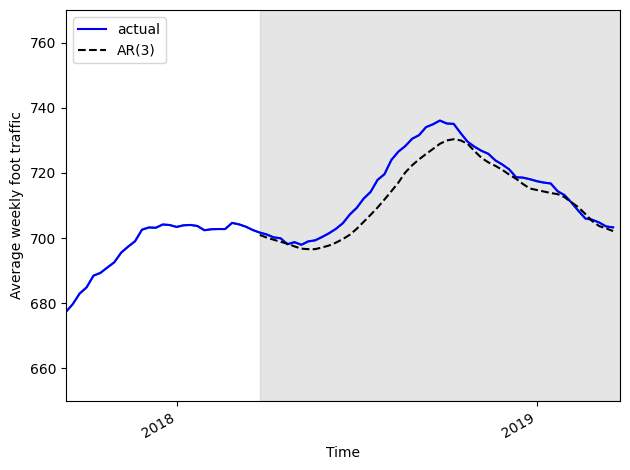

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['foot_traffic'])
ax.plot(df['foot_traffic'], 'b-', label='actual')
ax.plot(df['pred_foot_traffic'], 'k--', label='AR(3)')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')
ax.axvspan(948, 1000, color='#808080', alpha=0.2)
ax.set_xlim(920, 1000)
ax.set_ylim(650, 770)
plt.xticks([936, 988],[2018, 2019])
fig.autofmt_xdate()
plt.tight_layout()

Moving-average process

AIC (아카이케 정보기준)

모델의 품질을 다른 모델들과 비교하여 상대적으로 정량화

## 잔차

$$
\epsilon_t = y_t - \hat{y}_t = \text{residual}
$$

In [ ]:
from tqdm import tqdm_notebook  # 반복문 진행률 표시
from itertools import product   # 여러 조합 생성

AR(1), MA(1) 과정을 가정 ARMA(1, 1)

In [ ]:
np.random.seed(42)

ar1 = np.array([1, -0.33])
ma1 = np.array([1, 0.9])

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

In [ ]:
ADF_result = adfuller(ARMA_1_1)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -6.429878682042687
p-value: 1.707846668009726e-08


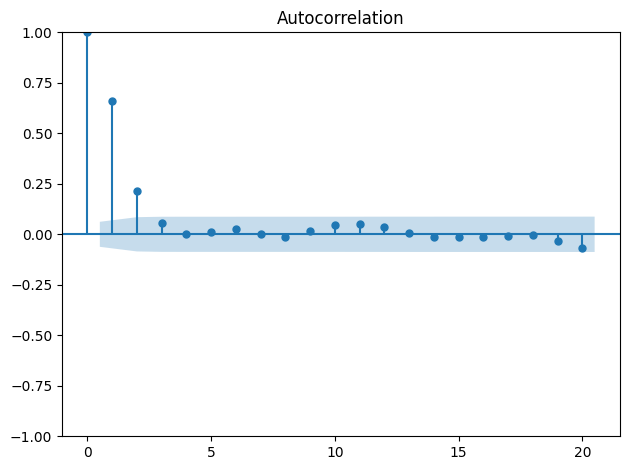

In [ ]:
plot_acf(ARMA_1_1, lags=20)
plt.tight_layout()
plt.show()

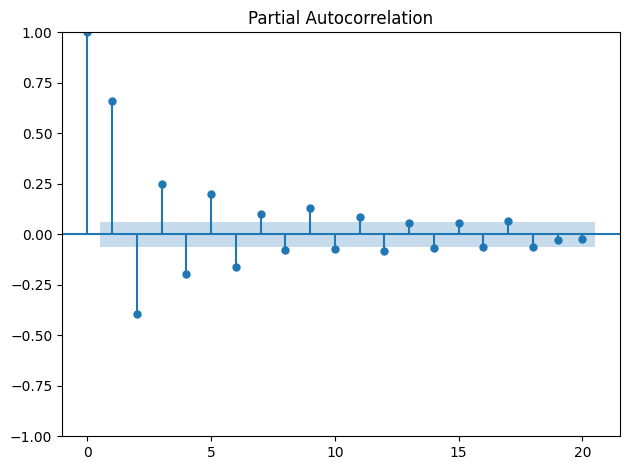

In [ ]:
plot_pacf(ARMA_1_1, lags=20)
plt.tight_layout()
plt.show()

p,q 목록 만들기

In [ ]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [ ]:
from typing import Union
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    # order_list = [(3, 3), ...], order=(3, 3) => (p, q)
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
        aic = model.aic
        results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [ ]:
result_df = optimize_ARMA(ARMA_1_1, order_list)

/tmp/ipykernel_23382/223008812.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
result_df

,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(3, 3)",2806.151032
8,"(2, 3)",2806.175380
9,"(3, 2)",2806.894930


$$
y_t = \phi_1 y_{t-1} + \epsilon_t + \theta_1 \epsilon_{t-1}
$$

In [ ]:
model = SARIMAX(ARMA_1_1, order=(1, 0, 1), simple_differencing=False)
model_fit = model.fit(disp=False)
# 잔차
residuals = model_fit.resid

In [ ]:
from statsmodels.graphics.gofplots import qqplot

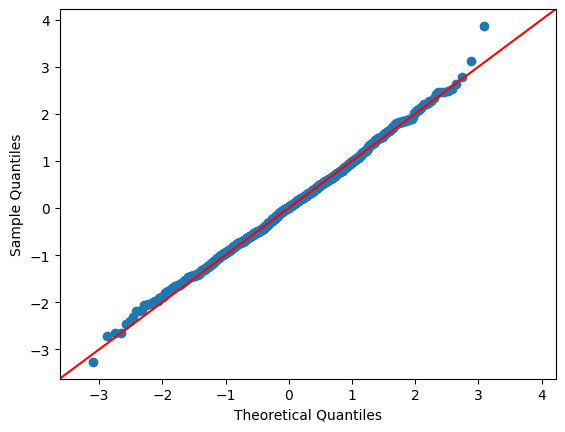

In [ ]:
qqplot(residuals, line='45');

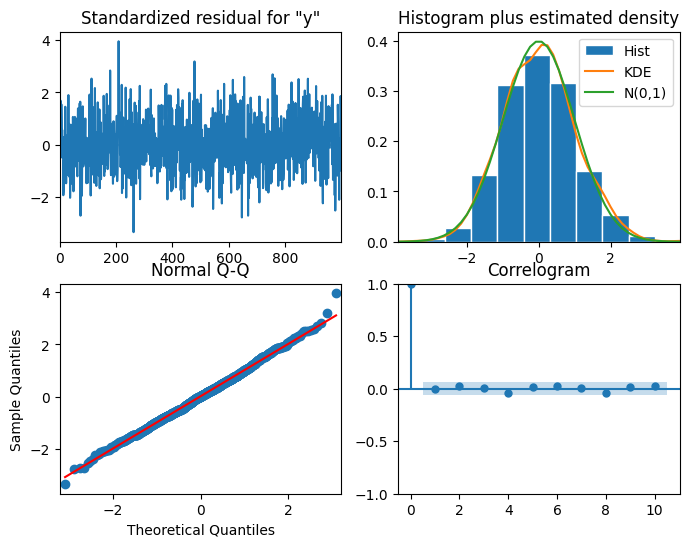

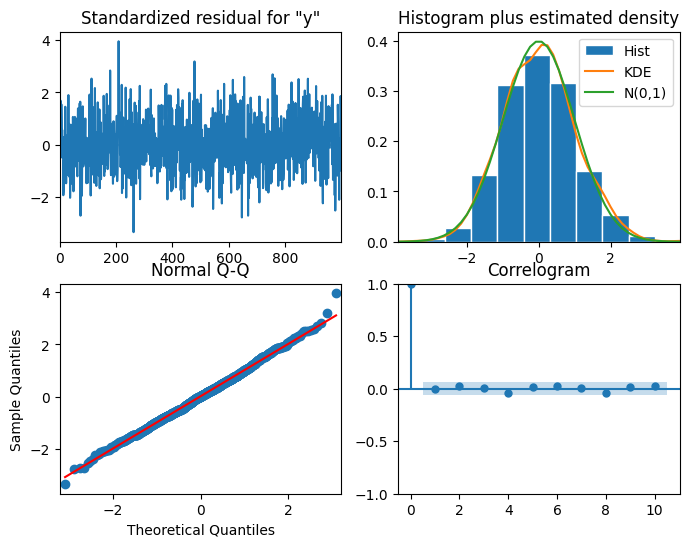

In [ ]:
model_fit.plot_diagnostics(figsize=(8, 6))

In [ ]:
# 융-박스 테스트
from statsmodels.stats.diagnostic import acorr_ljungbox

p-value값 : 0.05 이상이면 잔차가 백색소음으로 자기상관관계가 없음을 나타낸다.

In [ ]:
df = acorr_ljungbox(residuals, np.arange(1, 11, 1))

In [ ]:
df # 0.05가 넘어가서 귀무가설이 채택됨 자기상관관계가 없다.

,lb_stat,lb_pvalue
1,0.030706,0.860897
2,0.528021,0.767966
3,0.540904,0.909817
4,2.079774,0.721089
5,2.271897,0.810385
6,2.896262,0.821750
7,2.900378,0.894063
8,4.418799,0.817501
9,4.787567,0.852419
10,5.246805,0.874093


| 항목 | 값 | 의미 |
|---|---|---|
| `Log Likelihood` | -13990.802 | 로그 우도값 (높을수록 좋음) |
| `AIC` | 27991.604 | 정보 기준 (낮을수록 좋음) |
| `BIC` | 28027.570 | 정보 기준 (패널티 강함) |
| `HQIC` | 28003.788 | Hannan-Quinn 정보 기준 |

In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1397.704
Date:                Wed, 06 May 2026   AIC                           2801.408
Time:                        08:14:55   BIC                           2816.131
Sample:                             0   HQIC                          2807.004
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3103      0.032      9.572      0.000       0.247       0.374
ma.L1          0.9203      0.014     66.415      0.000       0.893       0.948
sigma2         0.9560      0.042     22.825      0.0

Outer Product of Gradients

| 기준 | 수식 | 패널티 계수 |
|------|------|------------|
| **AIC** | $-2\ln(\hat{L}) + 2k$ | $2$ |
| **BIC** | $-2\ln(\hat{L}) + k\ln(n)$ | $\ln(n)$ |
| **HQIC** | $$-2\ln(\hat{L}) + 2k\ln(\ln(n))$$ | $2\ln(\ln(n))$ |

In [ ]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon
    end_idx = train_len
    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value
    elif method == 'ARMA':
        pred_ARMA = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(2,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
        return pred_ARMA

In [ ]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [ ]:
pred_ARMA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'ARMA')